# Notebook 4 (Optional) — IBM TerraMind Tutorial: Fine-tune TerraMind with Sen1Floods11 Dataset 

Eun-Kyeong Kim (eun-kyeong.kim@lxp.lu, LuxProvide S.A) edited the original notebook provided by IBM to adapt it to up-to-date versions of dependencies.

## Sources: 
- Original Notebook: https://github.com/IBM/terramind/blob/main/notebooks%2Fterramind_v1_small_sen1floods11.ipynb 
- GitHub repository: https://github.com/IBM/terramind


## Setup

1. Use GPU or TPU node(s).
2. Install TerraTorch

In [1]:
import os
import setuptools
import torch
import gdown
import terratorch
import albumentations
import numpy as np
import lightning.pytorch as pl
import matplotlib.pyplot as plt
from pathlib import Path
from terratorch.datamodules import GenericNonGeoSegmentationDataModule

import warnings
warnings.filterwarnings("ignore")

3. Download the dataset from Google Drive

In [2]:
if not os.path.isfile("sen1floods11_v1.1.tar.gz"):
    gdown.download("https://drive.google.com/uc?id=1lRw3X7oFNq_WyzBO6uyUJijyTuYm23VS",
                   output="sen1floods11_v1.1.tar.gz",
                   quiet=True)
    !tar -xzf sen1floods11_v1.1.tar.gz 

## Fine-tuning via CLI

Fine-tune TerraMind with only a config file!

Locally, run the fine-tuning command in your terminal rather than in this notebook.
(For Macbook users: Error with MPS and some macOS version, fix https://github.com/terrastackai/terratorch/issues/859)

In [3]:
# Download config
if not os.path.isfile("terramind_v1_tiny_sen1floods11.yaml"):
    !wget https://raw.githubusercontent.com/IBM/terramind/refs/heads/main/configs/terramind_v1_tiny_sen1floods11.yaml

In [4]:
# Check the config
!cat terramind_v1_tiny_sen1floods11.yaml

# lightning.pytorch==2.1.1
seed_everything: 42
trainer:
  accelerator: auto
  strategy: auto
  devices: auto
  num_nodes: 1
  precision: 16-mixed
  logger: true
  callbacks:
    - class_path: RichProgressBar
    - class_path: LearningRateMonitor
      init_args:
        logging_interval: epoch
  max_epochs: 100
  log_every_n_steps: 5
  default_root_dir: output/terramind_tiny_sen1floods11/

data:
  class_path: terratorch.datamodules.GenericMultiModalDataModule
  init_args:
    task: 'segmentation'
    batch_size: 8
    num_workers: 4
    modalities:
      - S2L1C
      - S1GRD
    rgb_modality: S2L1C
    rgb_indices:
      - 3
      - 2
      - 1
    train_data_root:
      S2L1C: sen1floods11_v1.1/data/S2L1CHand
      S1GRD: sen1floods11_v1.1/data/S1GRDHand
    train_label_data_root: sen1floods11_v1.1/data/LabelHand
    val_data_root:
      S2L1C: sen1floods11_v1.1/data/S2L1CHand
      S1GRD: sen1floods11_v1.1/data/S1GRDHand
    val_label_data_root: sen1floods11_v1.1/data/LabelHand
    

In [5]:
# Run fine-tuning
# It takes a while. To see the progress and logs, check fine-tuning.log
!terratorch fit -c terramind_v1_tiny_sen1floods11.yaml > fine-tuning.log 2>&1

Let's explore the different settings of the config in a bit more detail ...

### Sen1Floods11 Dataset

Lets start with analysing the dataset

In [6]:
dataset_path = Path("sen1floods11_v1.1")
!ls "sen1floods11_v1.1/data"

CopernicusDEM  JRCWaterHand  LabelHand	S1GRDHand  S1OtsuLabelHand  S2L1CHand


In [7]:
!ls "sen1floods11_v1.1/data/S2L1CHand/" | head

Bolivia_103757_S2Hand.tif
Bolivia_129334_S2Hand.tif
Bolivia_195474_S2Hand.tif
Bolivia_23014_S2Hand.tif
Bolivia_233925_S2Hand.tif
Bolivia_242570_S2Hand.tif
Bolivia_290290_S2Hand.tif
Bolivia_294583_S2Hand.tif
Bolivia_312675_S2Hand.tif
Bolivia_314919_S2Hand.tif


TerraTorch provides generic data modules that work directly with PyTorch Lightning.

Sen1Floods11 is a multimodal dataset that provides Sentinel-2 L2A and Sentinel-1 GRD data. 
Therefore, we are using the `GenericMultiModalDataModule`. 
This module is similar to the `GenericNonGeoSegmentationDataModule`, which is used for standard segmentation tasks.
However, the data roots, `img_grep` are other settings are provided as dict to account for the multimodal inputs. You find all settings in the [documentation](https://terrastackai.github.io/terratorch/stable/generic_datamodules/).
In a Lightning config, the data module is defined with the `data` key.

In [8]:
datamodule = terratorch.datamodules.GenericMultiModalDataModule(
    task="segmentation",
    batch_size=8,
    num_workers=2,
    num_classes=2,

    # Define your input modalities. The names must match the keys in the following dicts.
    modalities=["S2L1C", "S1GRD"],
    rgb_indices={
        "S2L1C": [3, 2, 1],
        "S1GRD": [0, 1, 0],
    },

    # Define data paths as dicts using the modality names as keys.
    train_data_root={
        "S2L1C": dataset_path / "data/S2L1CHand",
        "S1GRD": dataset_path / "data/S1GRDHand",
    },
    train_label_data_root=dataset_path / "data/LabelHand",
    val_data_root={
        "S2L1C": dataset_path / "data/S2L1CHand",
        "S1GRD": dataset_path / "data/S1GRDHand",
    },
    val_label_data_root=dataset_path / "data/LabelHand",
    test_data_root={
        "S2L1C": dataset_path / "data/S2L1CHand",
        "S1GRD": dataset_path / "data/S1GRDHand",
    },
    test_label_data_root=dataset_path / "data/LabelHand",

    # Define split files because all samples are saved in the same folder.
    train_split=dataset_path / "splits/flood_train_data.txt",
    val_split=dataset_path / "splits/flood_valid_data.txt",
    test_split=dataset_path / "splits/flood_test_data.txt",
    
    # Define suffix, again using dicts.
    image_grep={
        "S2L1C": "*_S2Hand.tif",
        "S1GRD": "*_S1Hand.tif",
    },
    label_grep="*_LabelHand.tif",
    
    # With TerraTorch, you can select a subset of the dataset bands as model inputs by providing dataset_bands (all bands in the data) and output_bands (selected bands). This setting is optional for all modalities and needs to be provided as dicts.
    # Here is an example for with S-1 GRD. You could change the output to ["VV"] to only train on the first band. Note that means and stds must be aligned with the output_bands (equal length of values). 
    dataset_bands={
        "S1GRD": ["VV", "VH"]
    },
    output_bands={
        "S1GRD": ["VV", "VH"]
    },

    # Define standardization values. We use the pre-training values here and providing the additional modalities is not a problem, which makes it simple to experiment with different modality combinations. Alternatively, use the dataset statistics that you can generate using `terratorch compute_statistics -c config.yaml` (requires concat_bands: true for this multimodal datamodule).
    means={
      "S2L1C": [2357.089, 2137.385, 2018.788, 2082.986, 2295.651, 2854.537, 3122.849, 3040.560, 3306.481, 1473.847, 506.070, 2472.825, 1838.929],
      "S2L2A": [1390.458, 1503.317, 1718.197, 1853.910, 2199.100, 2779.975, 2987.011, 3083.234, 3132.220, 3162.988, 2424.884, 1857.648],
      "S1GRD": [-12.599, -20.293],
      "S1RTC": [-10.93, -17.329],
      "RGB": [87.271, 80.931, 66.667],
      "DEM": [670.665]
    },
    stds={
      "S2L1C": [1624.683, 1675.806, 1557.708, 1833.702, 1823.738, 1733.977, 1732.131, 1679.732, 1727.26, 1024.687, 442.165, 1331.411, 1160.419],
      "S2L2A": [2106.761, 2141.107, 2038.973, 2134.138, 2085.321, 1889.926, 1820.257, 1871.918, 1753.829, 1797.379, 1434.261, 1334.311],
      "S1GRD": [5.195, 5.890],
      "S1RTC": [4.391, 4.459],
      "RGB": [58.767, 47.663, 42.631],
      "DEM": [951.272],
    },
    
        # albumentations supports shared transformations and can handle multimodal inputs. 
    train_transform=[
        albumentations.D4(), # Random flips and rotation
        albumentations.pytorch.transforms.ToTensorV2(),
    ],
    val_transform=None,  # Using ToTensorV2() by default if not provided
    test_transform=None,
    
    no_label_replace=-1,  # Replace NaN labels. defaults to -1 which is ignored in the loss and metrics.
    no_data_replace=0,  # Replace NaN data
    check_stackability=False, # Set to True if you are uncertain if all samples have the same input shape
)

# Setup train and val datasets
datamodule.setup("fit")

2026-04-29 11:58:59,568 - INFO - Train dataset: 252
2026-04-29 11:58:59,659 - INFO - Val dataset: 89


In [9]:
# checking datasets validation split size
val_dataset = datamodule.val_dataset
len(val_dataset)

89

In [10]:
print(val_dataset[2])

{'mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 1, 1, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [0, 0, 1,  ..., 1, 1, 1]]), 'image': {'S2L1C': tensor([[[2065., 2065., 2065.,  ..., 1454., 1455., 1455.],
         [2065., 2065., 2065.,  ..., 1469., 1468., 1468.],
         [2065., 2065., 2065.,  ..., 1469., 1468., 1468.],
         ...,
         [1717., 1717., 1742.,  ..., 1693., 1693., 1693.],
         [1717., 1717., 1742.,  ..., 1693., 1693., 1693.],
         [1683., 1683., 1732.,  ..., 1693., 1693., 1693.]],

        [[1846., 1889., 1906.,  ..., 1200., 1190., 1197.],
         [1856., 1883., 1899.,  ..., 1187., 1191., 1173.],
         [1908., 1904., 1911.,  ..., 1181., 1176., 1186.],
         ...,
         [1500., 1500., 1632.,  ..., 1509., 1510., 1542.],
         [1458., 1458., 1595.,  ..., 1494., 1541., 1551.],
         [1412., 1412., 1504.,  ..., 1502., 1509., 1496.]],

        [[193

In [11]:
import types

# Define the wrapper
def safe_plot(self, sample, suptitle=None):
    # Fix the filename if it's a dict
    if isinstance(sample.get("filename"), dict):
        sample["filename"] = sample["filename"].get("S2L1C", "")
    
    # Fix the image structure so indices work
    if "S2L1C" not in sample and "image" in sample:
        sample["S2L1C"] = sample["image"]["S2L1C"]
        
    # Call the original plot method
    return self._original_plot(sample, suptitle)

# Apply the fix to your specific object
val_dataset.rgb_indices = {"S2L1C": [3, 2, 1]}
val_dataset._original_plot = val_dataset.plot
val_dataset.plot = types.MethodType(safe_plot, val_dataset)

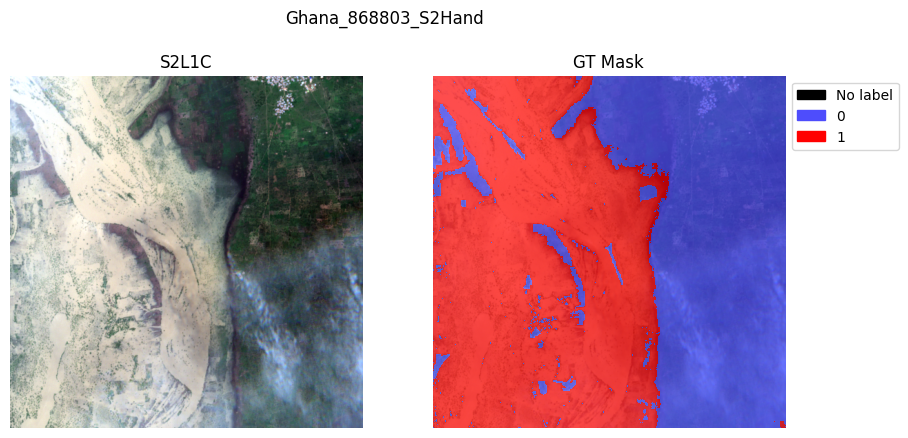

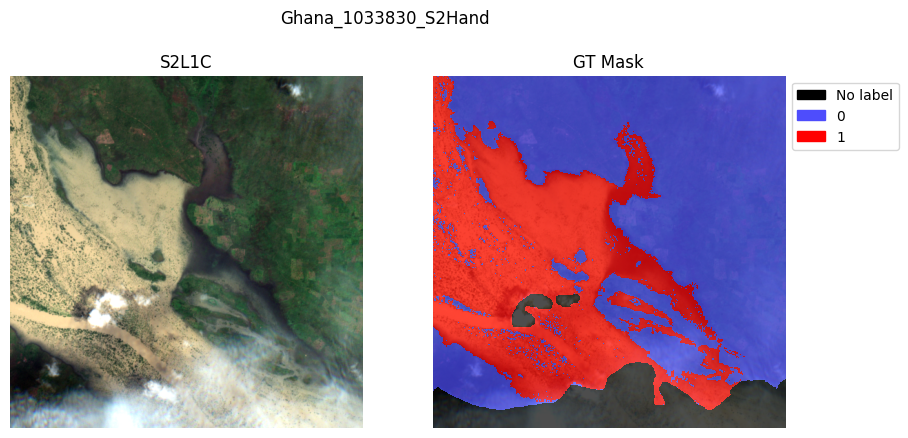

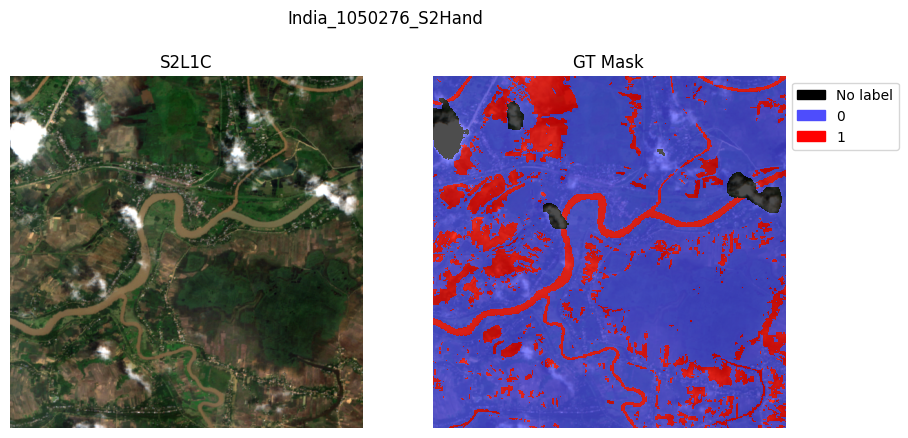

In [12]:
# The GenericMultiModalDataModule has an integrated plotting function with min/max scaling:
val_dataset.plot(val_dataset[2])
val_dataset.plot(val_dataset[8])
val_dataset.plot(val_dataset[11])
plt.show()

In [13]:
# checking datasets testing split size
datamodule.setup("test")
test_dataset = datamodule.test_dataset
len(test_dataset)

2026-04-29 11:59:09,753 - INFO - Test dataset: 90


90

## TerraTorch model registry

TerraTorch includes its own backbone registry with many EO FMs. It also includes meta registries for all model components that include other sources like timm image models or SMP decoders.

In [14]:
from terratorch.registry import BACKBONE_REGISTRY, TERRATORCH_BACKBONE_REGISTRY, TERRATORCH_DECODER_REGISTRY

In [15]:
# Print all TerraMind v1 backbones.  
[backbone   
 for backbone in TERRATORCH_BACKBONE_REGISTRY
 if 'terramind_v1' in backbone]
# TiM models are using the Thinking-in-Modalities approach, see our paper for details.

['terramind_v1_base',
 'terramind_v1_base_tim',
 'terramind_v1_large',
 'terramind_v1_large_tim',
 'terramind_v1_tiny',
 'terramind_v1_tiny_tim',
 'terramind_v1_small',
 'terramind_v1_small_tim',
 'terramind_v1_tokenizer_s2l2a',
 'terramind_v1_tokenizer_s1rtc',
 'terramind_v1_tokenizer_s1grd',
 'terramind_v1_tokenizer_dem',
 'terramind_v1_tokenizer_lulc',
 'terramind_v1_tokenizer_ndvi']

In [16]:
# Available decoders. We use the UNetDecoder in this example.
list(TERRATORCH_DECODER_REGISTRY)

['ASPPModule',
 'ASPPHead',
 'ASPPSegmentationHead',
 'ASPPRegressionHead',
 'FCNDecoder',
 'IdentityDecoder',
 'LinearDecoder',
 'MLPDecoder',
 'SatMAEHead',
 'UNetDecoder',
 'UperNetDecoder']

In [17]:
# Use the backbone registry to load a PyTorch model for a custom pipeline. The pre-trained weights are automatically downloaded with pretrained=True.
model = BACKBONE_REGISTRY.build(
    "terramind_v1_small",
    modalities=["S2L1C", "S1GRD"],
    pretrained=True,
)

# You find more information about the settings in the TerraMind docs: https://terrastackai.github.io/terratorch/stable/guide/terramind/

2026-04-29 11:59:11,190 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


In [18]:
model

TerraMindViT(
  (encoder_embeddings): ModuleDict(
    (untok_sen2l1c@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=3328, out_features=384, bias=False)
    )
    (untok_sen1grd@224): ImageEncoderEmbedding(
      (proj): Linear(in_features=512, out_features=384, bias=False)
    )
  )
  (encoder): ModuleList(
    (0-11): 12 x Block(
      (norm1): LayerNorm()
      (attn): Attention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm()
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (encoder_norm): LayerNorm()
  (to

## Fine-tune TerraMind via PyTorch Lightning

With TerraTorch, we can use standard Lightning components for the fine-tuning.
These include callbacks and the trainer class.
TerraTorch provides EO-specific tasks that define the training and validation steps.
In this case, we are using the `SemanticSegmentationTask`.
We refer to the [TerraTorch paper](https://arxiv.org/abs/2503.20563) for a detailed explanation of the TerraTorch tasks.

In [19]:
import terratorch.tasks  # Add this line to fix the AttributeError
import lightning.pytorch as pl

In [20]:
pl.seed_everything(0)

# By default, TerraTorch saves the model with the best validation loss. You can overwrite this by defining a custom ModelCheckpoint, e.g., saving the model with the highest validation mIoU.  
checkpoint_callback = pl.callbacks.ModelCheckpoint(
    dirpath="output/terramind_small_sen1floods11/checkpoints/",
    mode="max",
    monitor="val/mIoU", # Variable to monitor
    filename="best-mIoU",
    save_weights_only=True,
)

# Lightning Trainer
trainer = pl.Trainer(
    accelerator="auto",
    strategy="auto",
    devices=1, # Deactivate multi-gpu because it often fails in notebooks
    precision="16-mixed",  # Speed up training with half precision, delete for full precision training.
    num_nodes=1,
    logger=True,  # Uses TensorBoard by default
    max_epochs=3, # For demos
    log_every_n_steps=1,
    callbacks=[checkpoint_callback],
    default_root_dir="output/terramind_base_sen1floods11/",
)

# Segmentation mask that build the model and handles training and validation steps.  
model = terratorch.tasks.SemanticSegmentationTask(
    model_factory="EncoderDecoderFactory",  # Combines a backbone with necks, the decoder, and a head
    model_args={
        # TerraMind backbone
        "backbone": "terramind_v1_small",
        "backbone_pretrained": True,
        "backbone_modalities": ["S2L1C", "S1GRD"],
        # Optionally, define the input bands. This is only needed if you select a subset of the pre-training bands, as explained above.
        # "backbone_bands": {"S1GRD": ["VV"]},
        
        # Necks 
        "necks": [
            {
                "name": "SelectIndices",
                "indices": [2, 5, 8, 11] # indices for terramind_v1_base
                # "indices": [5, 11, 17, 23] # indices for terramind_v1_large
            },
            {"name": "ReshapeTokensToImage",
             "remove_cls_token": False},  # TerraMind is trained without CLS token, which neads to be specified.
            {"name": "LearnedInterpolateToPyramidal"}  # Some decoders like UNet or UperNet expect hierarchical features. Therefore, we need to learn a upsampling for the intermediate embedding layers when using a ViT like TerraMind.
        ],
        
        # Decoder
        "decoder": "UNetDecoder",
        "decoder_channels": [256, 128, 64, 32],
        # Warning for Mac users: The UNetDecoder can lead to some failures because of the batch norms when training on MPS.
        # Use a FCN decoder instead or install TerraTorch from main/v1.2.5 for a fix.
        
        # Head
        "head_dropout": 0.1,
        "num_classes": 2,
    },
    
    loss="dice",  # We recommend dice for binary tasks and ce for tasks with multiple classes. 
    optimizer="AdamW",
    lr=2e-5,  # The optimal learning rate varies between datasets, we recommend testing different once between 1e-5 and 1e-4. You can perform hyperparameter optimization using terratorch-iterate.  
    scheduler='ReduceLROnPlateau',  # optionally define a learning rate scheduler and pass hparams
    scheduler_hparams={
        'factor': 0.5,  # This "reduce LR on plateau" scheduler multiplies the lr by <factor> when the val loss did not improve for <patience> epochs
        'patience': 5
    },
    ignore_index=-1,
    freeze_backbone=True, # Only used to speed up fine-tuning in this demo, we highly recommend fine-tuning the backbone for the best performance.
    freeze_decoder=False,  # Should be false in most cases as the decoder is randomly initialized.
    plot_on_val=True,  # Plot predictions during validation steps
    class_names=["Others", "Water"],  # optionally define class names
    class_weights=[0.3, 0.7],  # optionally define class weights for in-balanced datasets
)

[rank: 0] Seed set to 0
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
2026-04-29 11:59:15,942 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


In [21]:
## This cell doesn't really work.
## Before starting the fine-tuning, you can start the tensorboard with:
# %reload_ext tensorboard
# %tensorboard --logdir output --executable python -m tensorboard.main

In [22]:
# Training
trainer.fit(model, datamodule=datamodule)

2026-04-29 11:59:20,535 - INFO - Train dataset: 252
2026-04-29 11:59:20,618 - INFO - Val dataset: 89
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │ 26.6 M │ train │     0 │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │     0 │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 3.9 M                                                                                            
Non-trainable params: 22.8 M                                                                                       
Total params: 26.6 M                                                                                               
Total estimated model params size (MB): 106                                                                        
Modules in train mode: 290                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=3` reached.


After fine-tuning, we can evaluate the model on the test set:

In [23]:
# Let's test the fine-tuned model
best_ckpt_path = "output/terramind_small_sen1floods11/checkpoints/best-mIoU.ckpt"
trainer.test(model, datamodule=datamodule, ckpt_path=best_ckpt_path)

# Note: This demo only trains for 5 epochs by default, which does not result in good test metrics.

2026-04-29 12:01:41,576 - INFO - Test dataset: 90
Restoring states from the checkpoint path at output/terramind_small_sen1floods11/checkpoints/best-mIoU.ckpt
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3     ]
Loaded model weights from the checkpoint at output/terramind_small_sen1floods11/checkpoints/best-mIoU.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric         ┃        DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/Accuracy        │     0.9148920774459839     │
│     test/Boundary_mIoU     │    0.07077613472938538     │
│ test/Class_Accuracy_Others │     0.925486147403717      │
│ test/Class_Accuracy_Water  │     0.9042980074882507     │
│       test/F1_Score        │     0.8500796556472778     │
│      test/IoU_Others       │     0.9129959344863892     │
│       test/IoU_Water       │     0.5944382548332214     │
│    test/Pixel_Accuracy     │     0.9228361248970032     │
│         test/loss          │     0.3882979154586792     │
│         test/mIoU          │     0.7537170648574829     │
│      test/mIoU_Micro       │     0.856727659702301      │
└────────────────────────────┴────────────────────────────┘

[{'test/loss': 0.3882979154586792,
  'test/Accuracy': 0.9148920774459839,
  'test/Boundary_mIoU': 0.07077613472938538,
  'test/Class_Accuracy_Others': 0.925486147403717,
  'test/Class_Accuracy_Water': 0.9042980074882507,
  'test/F1_Score': 0.8500796556472778,
  'test/IoU_Others': 0.9129959344863892,
  'test/IoU_Water': 0.5944382548332214,
  'test/Pixel_Accuracy': 0.9228361248970032,
  'test/mIoU': 0.7537170648574829,
  'test/mIoU_Micro': 0.856727659702301}]

2026-04-29 12:01:54,804 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"


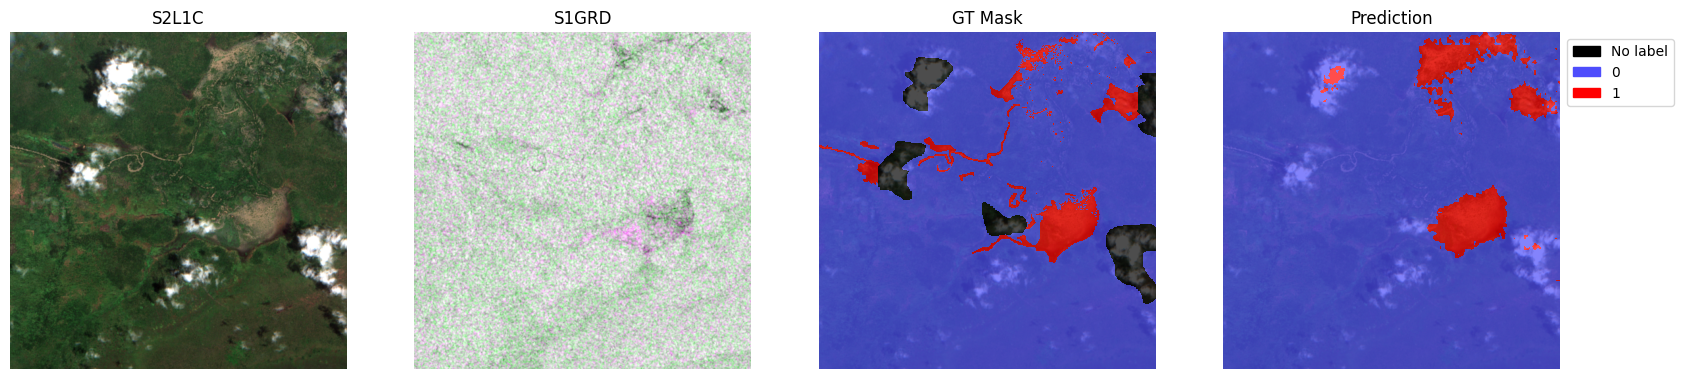

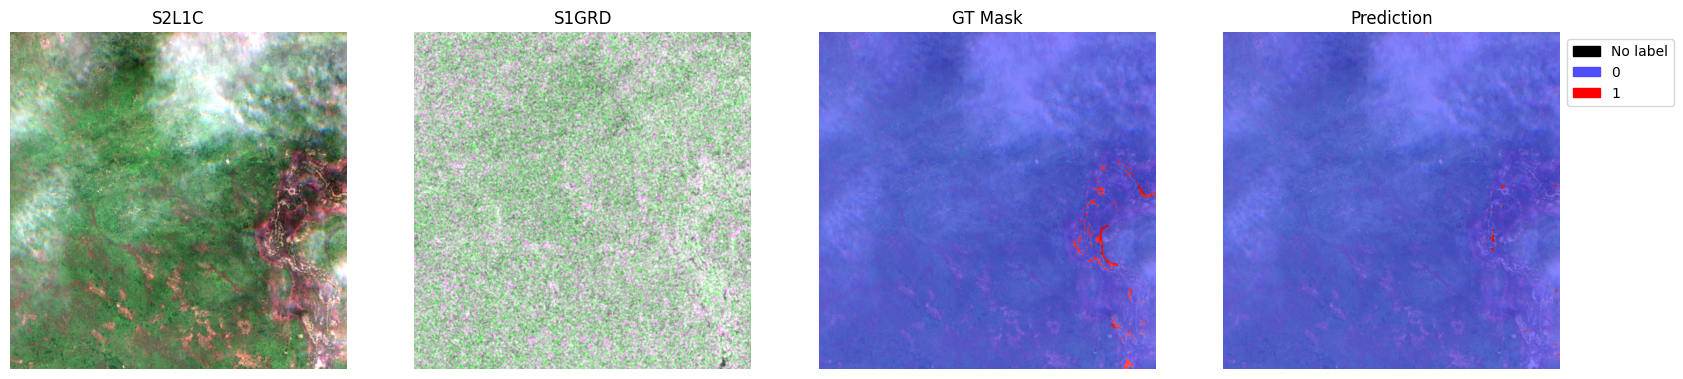

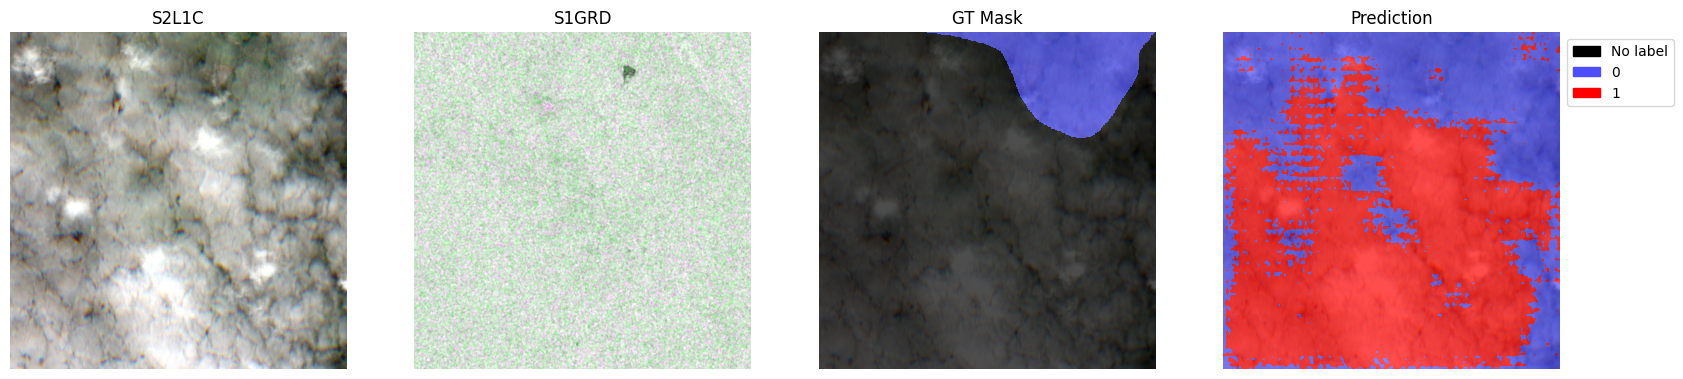

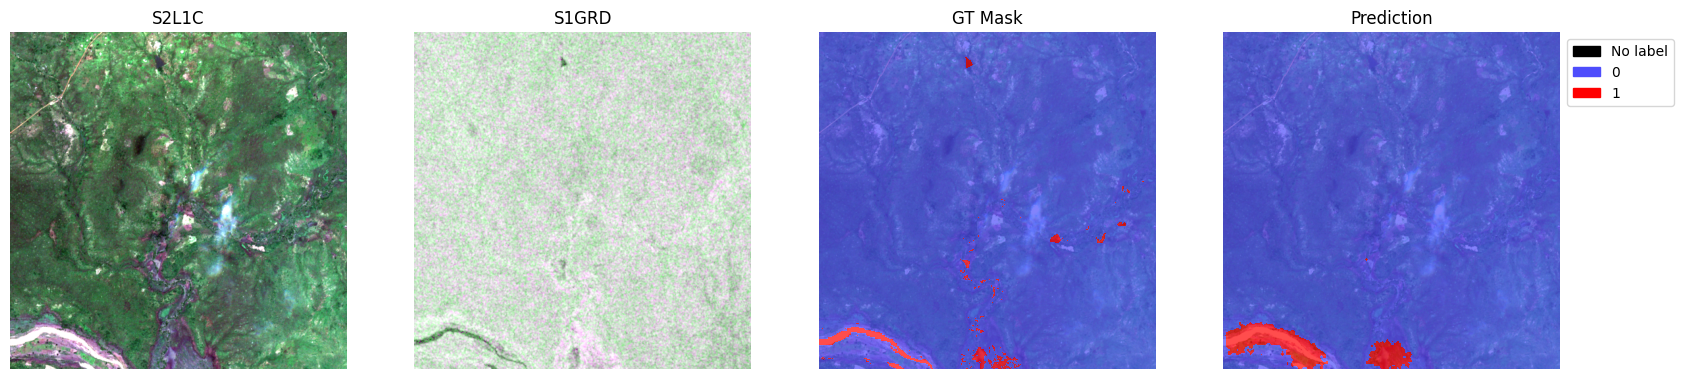

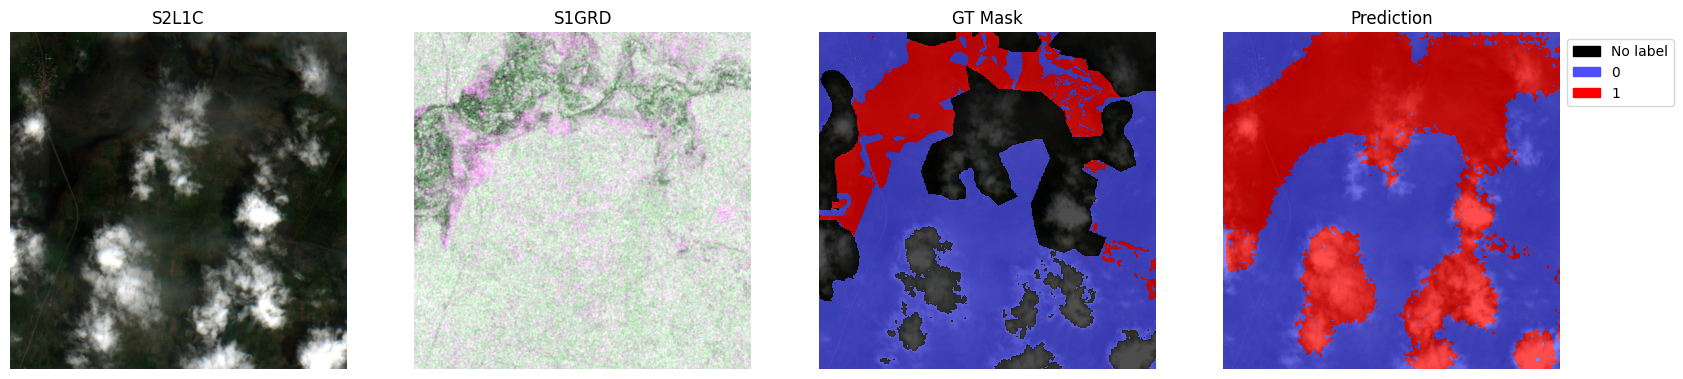

In [24]:
# Now we can use the model for predictions and plotting
model = terratorch.tasks.SemanticSegmentationTask.load_from_checkpoint(
    best_ckpt_path,
    model_factory=model.hparams.model_factory,
    model_args=model.hparams.model_args,
)
model.eval()

test_loader = datamodule.test_dataloader()
with torch.no_grad():
    batch = next(iter(test_loader))
    image = batch["image"].copy()
    batch = datamodule.aug(batch)
    input = batch["image"]
    for mod, value in input.items():
        input[mod] = value.to(model.device)
    masks = batch["mask"].numpy()

    with torch.no_grad():
        outputs = model(input)

    preds = torch.argmax(outputs.output, dim=1).cpu().numpy()

for i in range(5):
    sample = {
        "S2L1C": image["S2L1C"][i].cpu(),
        "S1GRD": image["S1GRD"][i].cpu(),
        "mask": batch["mask"][i],
        "prediction": preds[i],
    }
    test_dataset.plot(sample)
    plt.show()

# Note: This demo only trains for 5 epochs by default, which does not result in good predictions.